### Stock Market Prediction And Forecasting Using Stacked LSTM

In [93]:
### Keras and Tensorflow >2.0

In [94]:
### Data Collection
import pandas_datareader as pdr
key=""

In [95]:
import yfinance as yf

df = yf.download('AAPL', start='2020-01-01')

/tmp/ipykernel_306/2360681314.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [96]:
df.to_csv('/content/AAPL.csv')

In [97]:
import pandas as pd

In [98]:
df=pd.read_csv('AAPL.csv')

In [99]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,72.40050506591797,72.46076851156026,71.15666666509587,71.40977019424241,135480400
3,2020-01-03,71.69662475585938,72.45594269937853,71.47244650368873,71.62912999102163,146322800
4,2020-01-06,72.26792907714844,72.30649856939735,70.5685026643333,70.81920068576198,118387200


In [100]:
df.tail()

,Price,Close,High,Low,Open,Volume
1556,2026-03-11,260.80999755859375,262.1300048828125,259.54998779296875,261.0899963378906,26218900
1557,2026-03-12,255.75999450683594,258.95001220703125,254.17999267578125,258.6600036621094,40794000
1558,2026-03-13,250.1199951171875,256.3299865722656,249.52000427246094,255.47999572753906,36930000
1559,2026-03-16,252.82000732421875,253.88999938964844,249.8800048828125,252.11000061035156,32060100
1560,2026-03-17,254.57000732421875,255.12989807128906,252.17999267578125,253.07850646972656,10157072


In [101]:
df1 = df.iloc[2:]['Close'].astype(float)

In [102]:
df1

,Close
2,72.400505
3,71.696625
4,72.267929
5,71.928047
6,73.085114
...,...
1556,260.809998
1557,255.759995
1558,250.119995
1559,252.820007


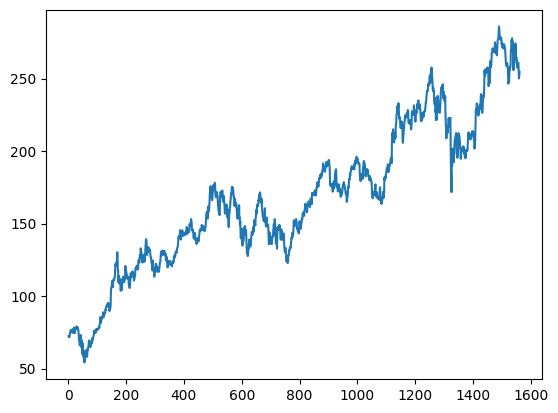

In [103]:
import matplotlib.pyplot as plt
plt.plot(df1)

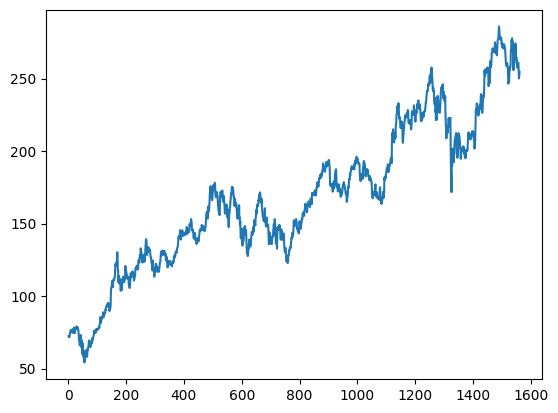

In [104]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [105]:
### LSTM are sensitive to the scale of the data. so we apply MinMax scaler

In [106]:
import numpy as np

In [107]:
df1

,Close
2,72.400505
3,71.696625
4,72.267929
5,71.928047
6,73.085114
...,...
1556,260.809998
1557,255.759995
1558,250.119995
1559,252.820007


In [108]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [109]:
print(df1)

[[0.07849029]
 [0.07545251]
 [0.07791812]
 ...
 [0.84548514]
 [0.85713775]
 [0.86469033]]


In [110]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [111]:
training_size,test_size

(1013, 546)

In [112]:
train_data

array([[0.07849029],
       [0.07545251],
       [0.07791812],
       ...,
       [0.55862578],
       [0.55683174],
       [0.56131675]])

In [113]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [114]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [115]:
print(X_train.shape), print(y_train.shape)

(912, 100)
(912,)


(None, None)

In [116]:
print(X_test.shape), print(ytest.shape)

(445, 100)
(445,)


(None, None)

In [117]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [118]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [119]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [120]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - loss: 0.0463 - val_loss: 0.0911
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.0058 - val_loss: 0.0285
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.0026 - val_loss: 0.0133
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 0.0018 - val_loss: 0.0087
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 0.0013 - val_loss: 0.0053
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 9.7342e-04 - val_loss: 0.0024
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - loss: 9.5497e-04 - val_loss: 0.0029
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 9.9773e-04 - val_loss: 0.0024
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - loss: 9.8549e-04 - val_loss: 0.0020
Epoch 12/100
15/15 ━━━━━━

In [123]:
import tensorflow as tf

In [124]:
tf.__version__

'2.19.0'

In [125]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [126]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [127]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

146.79198717118453

In [128]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

231.92964094849907

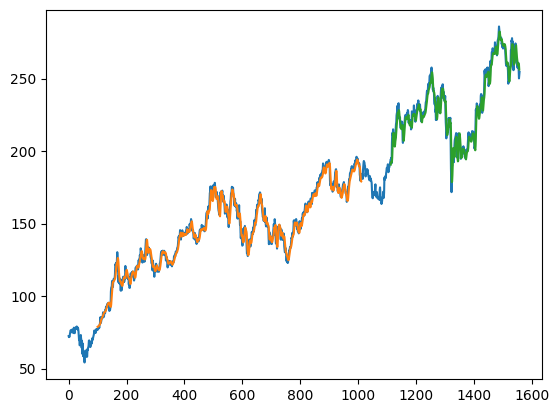

In [129]:
### Plotting
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [130]:
len(test_data)

546

In [135]:
x_input=test_data[len(test_data)-n_steps:].reshape(1,-1)
x_input.shape

(1, 100)

In [132]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [133]:
temp_input

[0.6324121517556741,
 0.6062089311117486,
 0.6274641332950879,
 0.6283676403991677,
 0.6263454176475582,
 0.6302178543639072,
 0.6338750825368062,
 0.6406303127654145,
 0.63869409440724,
 0.6292712792098224,
 0.6434269701776638,
 0.6327994349392815,
 0.6380486004834652,
 0.6213113289402495,
 0.6231184090016966,
 0.6112860220157748,
 0.6197623937656824,
 0.6078009343363207,
 0.6118453798395396,
 0.630863216581107,
 0.6330145117761565,
 0.6278512847721204,
 0.6332727225163239,
 0.630863216581107,
 0.6312074317147095,
 0.6488053398718623,
 0.6602074414774594,
 0.6800857831263891,
 0.6848617269468178,
 0.6693720459347094,
 0.6696301908215894,
 0.6744922048887406,
 0.6799566448296617,
 0.6745783409887506,
 0.663649526960196,
 0.6657578199585279,
 0.6702756188920768,
 0.6696733247248818,
 0.6746642795288981,
 0.6802577919132591,
 0.6885188892664295,
 0.6874432416689047,
 0.6857652340508976,
 0.686281589677945,
 0.6870130221418673,
 0.6750516285657929,
 0.665499675071648,
 0.6591317280266471,

In [136]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0

# Ensure temp_input starts with n_steps elements. It's already done in v0law4h-mwb2.

while(i<30):
    # If temp_input has grown, trim it to the last n_steps elements
    if(len(temp_input) > n_steps):
        temp_input = temp_input[len(temp_input) - n_steps:]

    # Convert the current window of temp_input to the required LSTM input shape
    x_input_for_predict = np.array(temp_input).reshape((1, n_steps, 1))

    # Make prediction
    yhat = model.predict(x_input_for_predict, verbose=0)
    # Print the prediction output directly
    print(f"{i} day output {yhat[0][0]}") # Access the scalar value from yhat

    # Add the prediction to the overall output list
    lst_output.extend(yhat.tolist())

    # Extend temp_input with the new prediction for the next iteration
    temp_input.extend(yhat[0].tolist()) # yhat[0] is array([float]), tolist() gives [float]

    i=i+1


print(lst_output)


0 day output 0.860032320022583
1 day output 0.8604631423950195
2 day output 0.8614608645439148
3 day output 0.8624292016029358
4 day output 0.8631636500358582
5 day output 0.8635604977607727
6 day output 0.8635641932487488
7 day output 0.8631623387336731
8 day output 0.8623806834220886
9 day output 0.861274242401123
10 day output 0.8599148988723755
11 day output 0.8583801984786987
12 day output 0.8567444086074829
13 day output 0.8550724387168884
14 day output 0.8534153699874878
15 day output 0.8518089652061462
16 day output 0.8502742052078247
17 day output 0.8488184809684753
18 day output 0.8474388122558594
19 day output 0.8461238145828247
20 day output 0.8448581695556641
21 day output 0.8436239361763
22 day output 0.8424032330513
23 day output 0.8411798477172852
24 day output 0.8399413228034973
25 day output 0.8386775255203247
26 day output 0.8373828530311584
27 day output 0.8360549211502075
28 day output 0.8346930742263794
29 day output 0.8332999348640442
[[0.860032320022583], [0.860

In [138]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [139]:
import matplotlib.pyplot as plt

In [140]:
len(df1)

1559

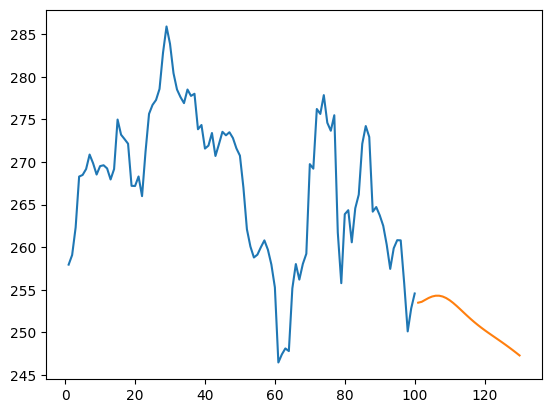

In [142]:
plt.plot(day_new,scaler.inverse_transform(df1[len(df1)-n_steps:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

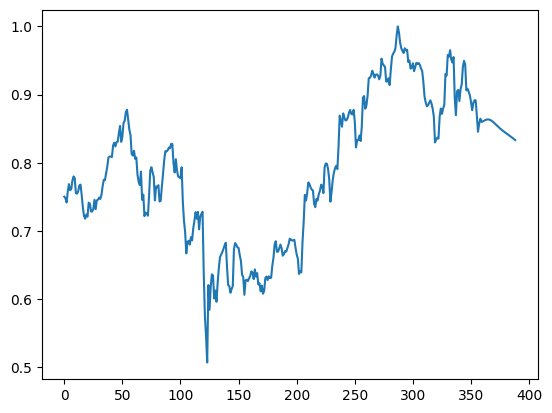

In [143]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [144]:
df3=scaler.inverse_transform(df3).tolist()

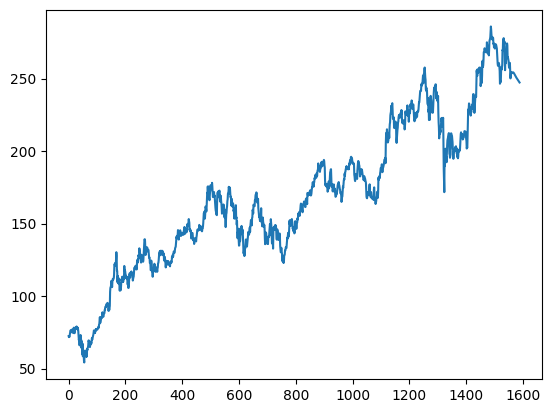

In [145]:
plt.plot(df3)